### Part 2: Poetry generation (for real)

Let's try to generate some poetry using RNNs.

You have several choices here:

* The Shakespeare sonnets, file `sonnets.txt` available in the notebook directory.

* Роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина. В предобработанном виде доступен по [ссылке](https://github.com/attatrol/data_sources/blob/master/onegin.txt).

* Some other text source, if it will be approved by the course staff.

Text generation can be designed in several steps:
    
1. Data loading.
2. Dictionary generation.
3. Data preprocessing.
4. Model (neural network) training.
5. Text generation (model evaluation).


In [1]:
import string
import os

### Data loading: Shakespeare

Shakespeare sonnets are awailable at this [link](http://www.gutenberg.org/ebooks/1041?msg=welcome_stranger). In addition, they are stored in the same directory as this notebook (`sonnetes.txt`). Simple preprocessing is already done for you in the next cell: all technical info is dropped.

In [2]:
'''
if not os.path.exists('sonnets.txt'):
    !wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_basic/homeworks_basic/lab02_deep_learning/sonnets.txt

with open('sonnets.txt', 'r') as iofile:
    text = iofile.readlines()

TEXT_START = 45
TEXT_END = -368
text = text[TEXT_START : TEXT_END]
assert len(text) == 2616
'''

"\nif not os.path.exists('sonnets.txt'):\n    !wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_basic/homeworks_basic/lab02_deep_learning/sonnets.txt\n\nwith open('sonnets.txt', 'r') as iofile:\n    text = iofile.readlines()\n\nTEXT_START = 45\nTEXT_END = -368\ntext = text[TEXT_START : TEXT_END]\nassert len(text) == 2616\n"

In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [3]:
# Join all the strings into one and lowercase it
# Put result into variable text.

# Your great code here
'''
assert len(text) == 100225, "Are you sure you have concatenated all the strings?"
assert not any([x in set(text) for x in string.ascii_uppercase]), "Uppercase letters are present"
print("OK!")
'''

'\nassert len(text) == 100225, "Are you sure you have concatenated all the strings?"\nassert not any([x in set(text) for x in string.ascii_uppercase]), "Uppercase letters are present"\nprint("OK!")\n'

### Data loading: "Евгений Онегин"


In [4]:
!wget https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt

with open('onegin.txt', 'r') as iofile:
    text = iofile.readlines()

text = [x.replace('\t\t', '') for x in text]

--2024-12-07 15:41:30--  https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 262521 (256K) [text/plain]
Saving to: ‘onegin.txt’

onegin.txt          100%[===================>] 256.37K  --.-KB/s    in 0.004s  

2024-12-07 15:41:31 (66.6 MB/s) - ‘onegin.txt’ saved [262521/262521]



In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [5]:
# Join all the strings into one and lowercase it
# Put result into variable text.

onegin = ""
for string in text:
    onegin += string.lower()


Put all the characters, that you've seen in the text, into variable `tokens`.

In [6]:
out = onegin
tokens = sorted(set(out))

Create dictionary `token_to_idx = {<char>: <index>}` and dictionary `idx_to_token = {<index>: <char>}`

In [7]:
token_to_idx = {x: idx for idx, x in enumerate(tokens)}

idx_to_token = {idx: x for idx, x in enumerate(tokens)}

n_tokens = len(tokens)
assert len(token_to_idx) == 83


*Comment: in this task we have only 38 (83) different tokens, so let's use one-hot encoding.*

### Building the model

Now we want to build and train recurrent neural net which would be able to something similar to Shakespeare's poetry.

Let's use vanilla RNN, similar to the one created during the lesson.

In [81]:
import torch
import torch.nn as nn

class VanilaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size = n_tokens, n_layers=1):
        super(VanilaRNN, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers

        self.rnn = nn.RNN(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, input, hidden):
        out, h = self.rnn(input.view(1, 1, -1).float(), hidden)
        out = self.fc(out)
        return out, hidden

    def init_hidden(self):
        return torch.zeros(self.n_layers, 1, self.hidden_size)


In [55]:
import random

chunk_len = 200

def random_chunk():
    start_index = random.randint(0, len(onegin) - chunk_len)
    end_index = start_index + chunk_len + 1
    return onegin[start_index: end_index]

def get_tensor(string):
    tensor = torch.zeros(len(string)).long()
    for c in range(len(string)):
        tensor[c] = token_to_idx[string[c]]
    return tensor

def train(inp, target):
    hidden = model.init_hidden()
    model.zero_grad()
    loss = 0

    for c in range(chunk_len - 1):
        output, hidden = model(inp[c], hidden)
        loss += criterion(output.view(1, -1), target[c].view(1))

    loss.backward()
    opt.step()

    return loss.item() / chunk_len

hidden_size = 100
lr = 0.005

model = VanilaRNN(1, hidden_size)
opt = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

losses = []

n_epochs = 500
n_average = 10
avg_loss = 0
for epoch in range(1, n_epochs + 1):
    train_tensor = get_tensor(random_chunk())
    loss = train(train_tensor[:-1], train_tensor[1:])
    avg_loss += loss

    if epoch % n_average == 0:
        losses.append(avg_loss / n_average)
        avg_loss = 0



```
# This is formatted as code
```

Plot the loss function (axis X: number of epochs, axis Y: loss function).

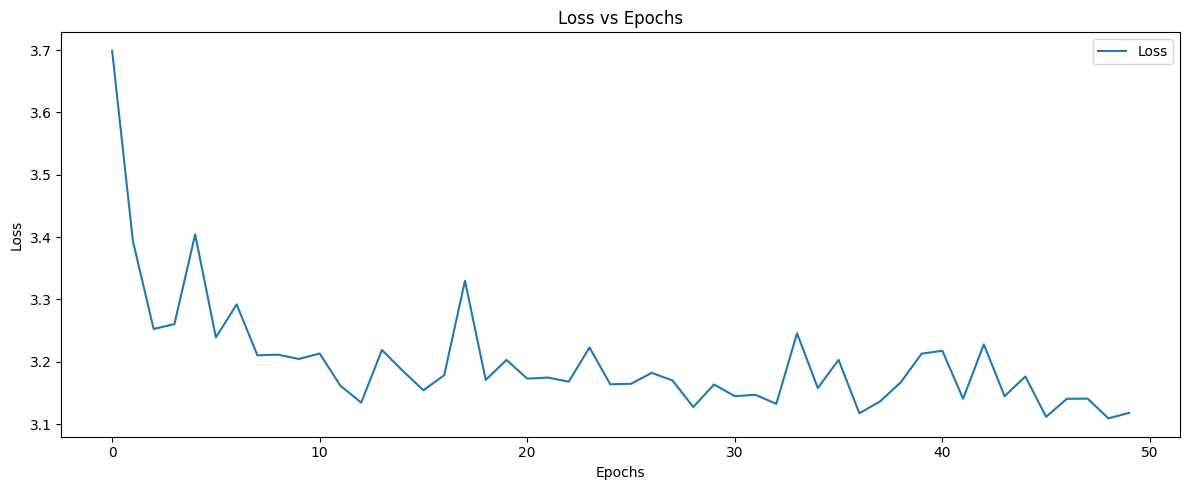

In [56]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12, 5))

plt.plot(losses, label='Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [87]:
MAX_LENGTH = 100
def generate_sample(char_rnn, seed_phrase="мoй дядя", length=MAX_LENGTH, temperature=1.0):
    """
    ### Disclaimer: this is an example function for text generation.
    ### You can either adapt it in your code or create your own function

    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
        smaller temperature converges to the single most likely output.

    Be careful with the model output. This model waits logits (not probabilities/log-probabilities)
    of the next symbol.
    """

    assert len(seed_phrase) > 1

    x_sequence = get_tensor(seed_phrase)
    hid_state = char_rnn.init_hidden()

    for i in range(len(seed_phrase)):
        _, hid_state = char_rnn(x_sequence[i], hid_state)
    inp = x_sequence[-1]

    sequence = ""
    # start generating
    while len(sequence) != length:
        output, hidden = char_rnn(inp, hid_state)

        output_dist = output.data.view(-1).div(temperature).exp()
        inp = torch.multinomial(output_dist, 1)[0]
        predicted_char = idx_to_token[inp.item()]
        sequence += predicted_char

    return sequence

In [78]:
# An example of generated text.
print(generate_sample(model, length=500, temperature=1.1))

 е,
сь ось ли на, га,
чнь о от ока буты; я ом мнань,
пата, сть и т нойстру «
г за: чт.
сь бунь ль ж м сь ль ть чем о лат сь скк я питнн,
каль в тт, вна пе онубу у
пет.
т,
б!
ннь сха ба м
гль пь м, 
к, сем нь знь?».к чь их ть ри еть лу паннот нот, в, ма
нь паь, лсь сь он си м
пы су м
у,
г петь б, зга. м знноват л;
м;
гу учь
р сь.
ва»я ву…
дндда ла кь ю
ом, у!
т,
бря э пить ве и,
омск в м
длыь
нь нь овинь зда!
а ^ь сты; би бь:
ды м я вох дна ди я,
почт пос;
пет сь кь ва сь м. прыриль не, и мнаст, 


### More poetic model

Let's use LSTM instead of vanilla RNN and compare the results.

*Comment: if you wish, you can use small GPT as well (e.g. from https://github.com/karpathy/nanoGPT)*

Plot the loss function of the number of epochs. Does the final loss become better?

> Yes, the final error was significantly reduced, by 25%!



In [60]:
class LSTMModel(nn.Module):
    def __init__(self, n_tokens, hidden_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(n_tokens, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size)
        self.fc = nn.Linear(hidden_size, n_tokens)

    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output, hidden = self.lstm(embedded, hidden)
        output = self.fc(output.view(1, -1))
        return output, hidden

    def init_hidden(self):
        return (torch.zeros(1, 1, self.hidden_size), torch.zeros(1, 1, self.hidden_size))

In [61]:
def train_lstm(inp, target):
    hidden = model.init_hidden()
    model.zero_grad()
    loss = 0

    for c in range(chunk_len):
        output, hidden = model(inp[c], hidden)
        loss += criterion(output.view(1, -1), target[c].view(1))

    loss.backward()
    opt.step()

    return loss.item() / chunk_len

model = LSTMModel(n_tokens, hidden_size)
opt = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

lstm_losses = []
avg_loss = 0
for epoch in range(1, n_epochs + 1):
    train_tensor = get_tensor(random_chunk())

    loss = train_lstm(train_tensor[:-1], train_tensor[1:])
    avg_loss += loss

    if epoch % n_average == 0:
        lstm_losses.append(avg_loss / n_average)
        avg_loss = 0

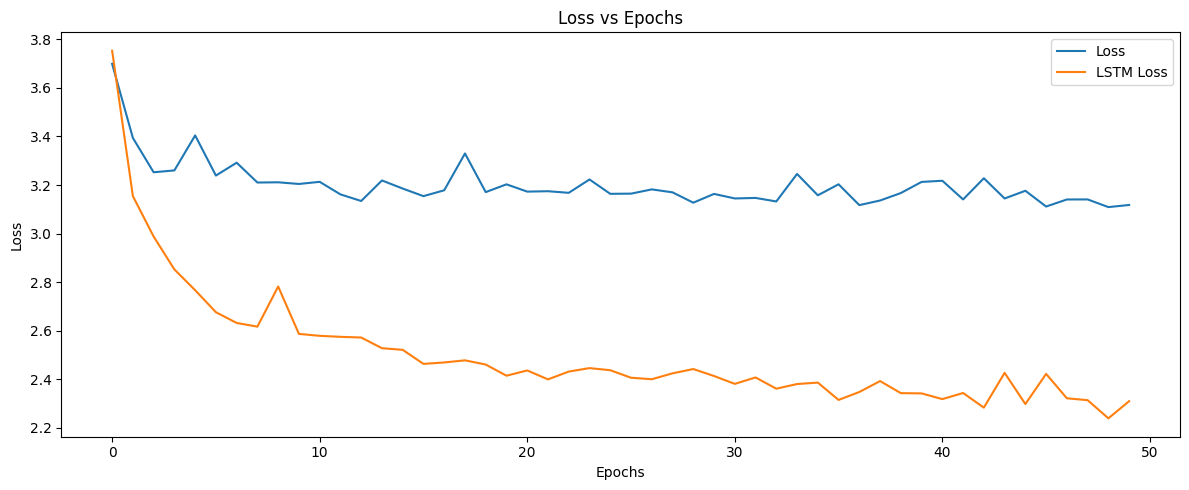

In [63]:
plt.figure(figsize=(12, 5))

assert (len(lstm_losses) == len(losses))
plt.plot(losses, label='Loss')
plt.plot(lstm_losses, label='LSTM Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Conclusion

We can see how a minor change in the model affected the Loss result

Generate text using the trained net with different `temperature` parameter: `[0.1, 0.2, 0.5, 1.0, 2.0]`.

Evaluate the results visually, try to interpret them.

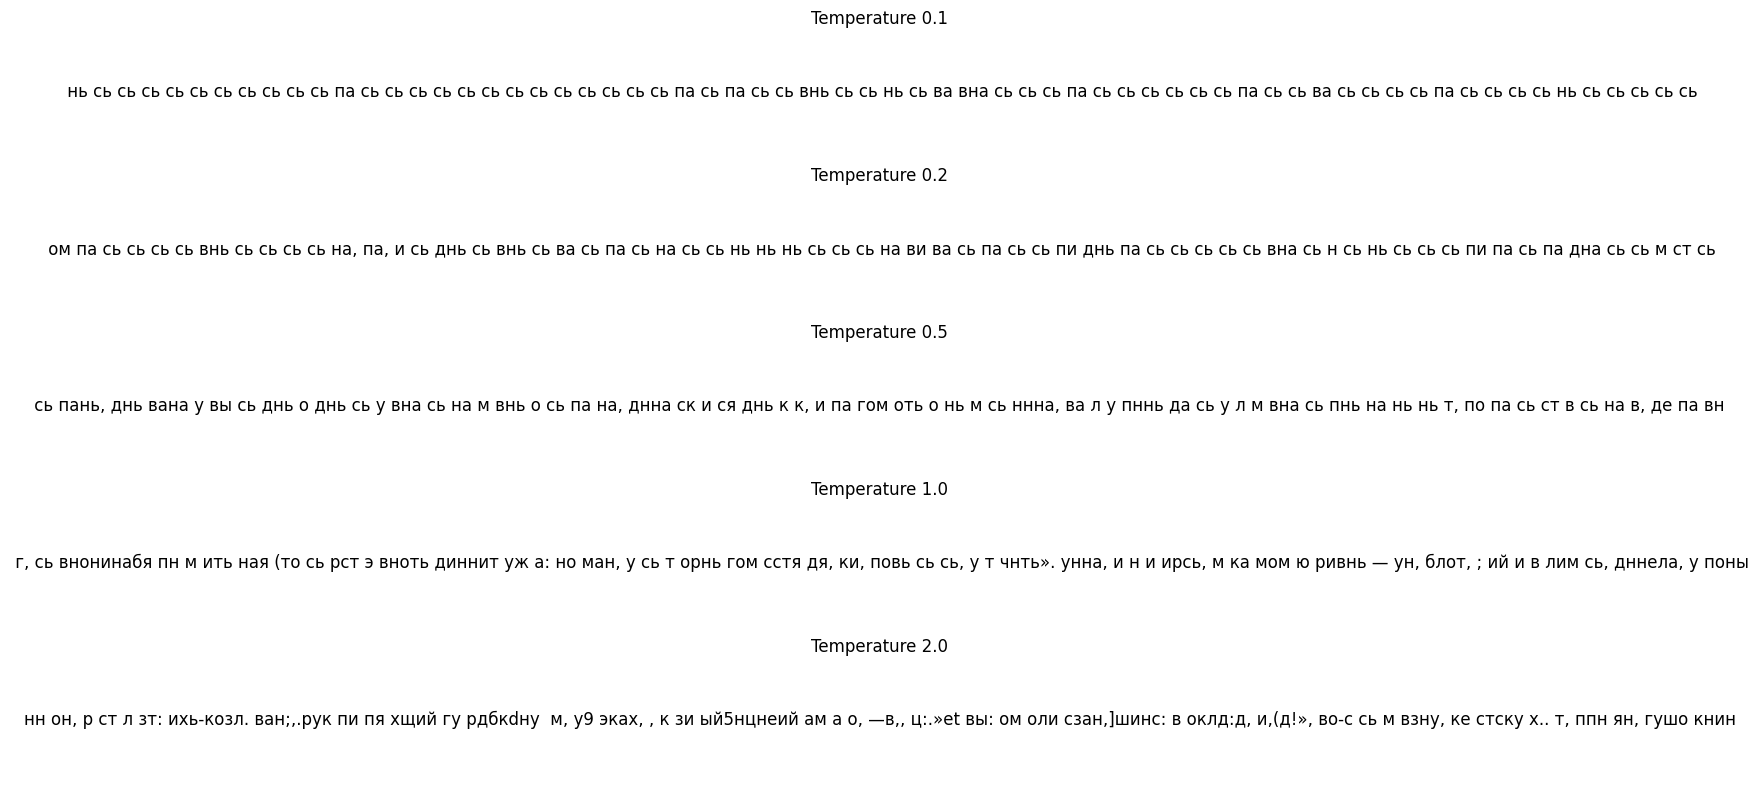

In [79]:
# Text generation with different temperature values here
temperatures = [0.1, 0.2, 0.5, 1.0, 2.0]
texts = {}

for temp in temperatures:
    texts[temp] = generate_sample(model, length=200, temperature=temp)

# Create a figure to display results
plt.figure(figsize=(15, 8))
for i, (temp, text) in enumerate(texts.items()):
    plt.subplot(len(texts), 1, i + 1)
    plt.title(f'Temperature {temp}')
    plt.text(0.5, 0.5, text.replace('\n', ' '), fontsize=12, ha='center', va='center')
    plt.axis('off')

plt.tight_layout()
plt.show()

## Conclusion

It is perfectly visible that at low temperatures the character sets are often repeated. This is clearly visible at temperatures of 0.1 and 0.2, approaching 1 the situation stabilizes. But with further increase the symbols become very diverse.

### Saving and loading models

Save the model to the disk, then load it and generate text. Examples are available [here](https://pytorch.org/tutorials/beginner/saving_loading_models.html]).

In [86]:
model_path = 'rnn_model.pth'
torch.save(model.state_dict(), model_path)

loaded_model = LSTMModel(n_tokens, hidden_size)

loaded_model.load_state_dict(torch.load(model_path, weights_only=True))
loaded_model.eval()
print(generate_sample(loaded_model, length=500, temperature=1.1))

 у ж, с, ит
оь ль ск,
эть снну.
на,
ча нов ть ф,
рускость ом вететск, чна п о знат г; т)» стн пь и, пося, и:
к сь иснаны, да см де нсь ва:
д см ст ланич
см
к, сь натсьсь га лсечау сь оль с жннобь я,
пань трнь д,
лу сль, м)ою: дат
пум ца пет9
илосл с
гуть снь вйн,
нь о лане г,  ви боб,
нню на ом пе тесь чировит к с, оча м вату ск, чт ись, нь,
ска:
н о жн я, ь, ль;
у, рут,
пи…
ойсь г пна,
инече бруну сь о х и ужуiю;
ми чно л л,
чесат ви. вь, л л н:
е пи, на,
м.
и
бем на д ба, сь бь, всья нь,
и бл 


### References
1. <a href='http://karpathy.github.io/2015/05/21/rnn-effectiveness/'> Andrew Karpathy blog post about RNN. </a>
There are several examples of genration: Shakespeare texts, Latex formulas, Linux Sourse Code and children names.
2. <a href='https://github.com/karpathy/char-rnn'> Repo with char-rnn code </a>
3. Cool repo with PyTorch examples: [link](https://github.com/spro/practical-pytorch)
4. nanoGPT by Andrej Karpathy: https://github.com/karpathy/nanoGPT